# AAI614: Data Science & its Applications

*Notebook 5.4: Experiment with KNN*

<a href="https://colab.research.google.com/github/techseeko/AAI614_Haidar/blob/main/Week-5/Saoud-Notebook5.4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Example I: Classifying Social Networks Ads

## Importing the libraries

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [33]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

dataset = pd.read_csv('https://raw.githubusercontent.com/techseeko/AAI614_Haidar/refs/heads/main/Week-5/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
y = dataset.iloc[:, 4].values

## Splitting the dataset into the Training set and Test set

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)


## Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Fitting K-NN to the Training set

Use the KNN model for training by specifying the input and output variables of the training set as follows.  Note that *p =2* refers to **euclidean distance**.

In [36]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
classifier.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Predicting the Test set results

In [37]:
y_pred = classifier.predict(X_test)

## Making the Confusion Matrix

In [38]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[64,  4],
       [ 3, 29]])

## Optimizing Example I

The model above used an arbitrary `k = 5` and was judged on a single train/test split. Following the lessons in week 5, we now (a) get a more reliable estimate with **cross-validation**, (b) pick the best `k` from a **validation curve**, and (c) tune all hyperparameters with **grid search**.

k=5  ->  5-fold CV accuracy: 0.903 (+/- 0.046)


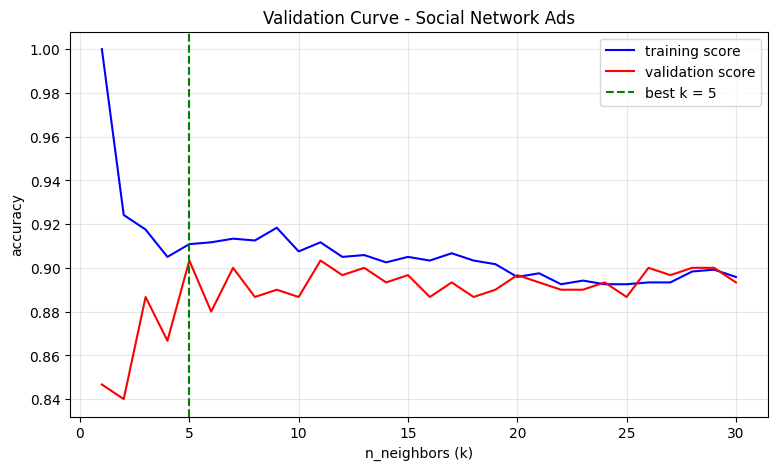


Best params: {'n_neighbors': np.int64(6), 'p': 2, 'weights': 'distance'}
Best CV accuracy: 0.907
Tuned model test accuracy:    0.930
Original k=5 test accuracy:   0.930


In [39]:
from sklearn.model_selection import cross_val_score, validation_curve, GridSearchCV

# (a) Cross-validation of the original k=5 model
cv_scores = cross_val_score(classifier, X_train, y_train, cv=5)
print("k=5  ->  5-fold CV accuracy: {:.3f} (+/- {:.3f})".format(cv_scores.mean(), cv_scores.std()))

# (b) Validation curve: training vs. validation accuracy across k
k_range = np.arange(1, 31)
train_score, val_score = validation_curve(
    KNeighborsClassifier(), X_train, y_train,
    param_name='n_neighbors', param_range=k_range, cv=5)

best_k = k_range[np.argmax(np.mean(val_score, axis=1))]

plt.figure(figsize=(9, 5))
plt.plot(k_range, np.mean(train_score, axis=1), color='blue', label='training score')
plt.plot(k_range, np.mean(val_score, axis=1), color='red', label='validation score')
plt.axvline(best_k, color='green', linestyle='--', label='best k = {}'.format(best_k))
plt.xlabel('n_neighbors (k)')
plt.ylabel('accuracy')
plt.title('Validation Curve - Social Network Ads')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# (c) Grid search over k, weighting scheme and distance metric
param_grid = {'n_neighbors': np.arange(1, 31), 'weights': ['uniform', 'distance'], 'p': [1, 2]}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("\nBest params:", grid.best_params_)
print("Best CV accuracy: {:.3f}".format(grid.best_score_))
print("Tuned model test accuracy:    {:.3f}".format(grid.best_estimator_.score(X_test, y_test)))
print("Original k=5 test accuracy:   {:.3f}".format(classifier.score(X_test, y_test)))

# Example II: Classifying Digits

In [40]:
from sklearn import metrics

In [41]:
from sklearn.datasets import load_digits
digits = load_digits()
# Train the model using the training sets
x_train, x_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.25)

In [42]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [43]:
#Predict Output
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, model.predict(x_test))
score = model.score(x_test, y_test)

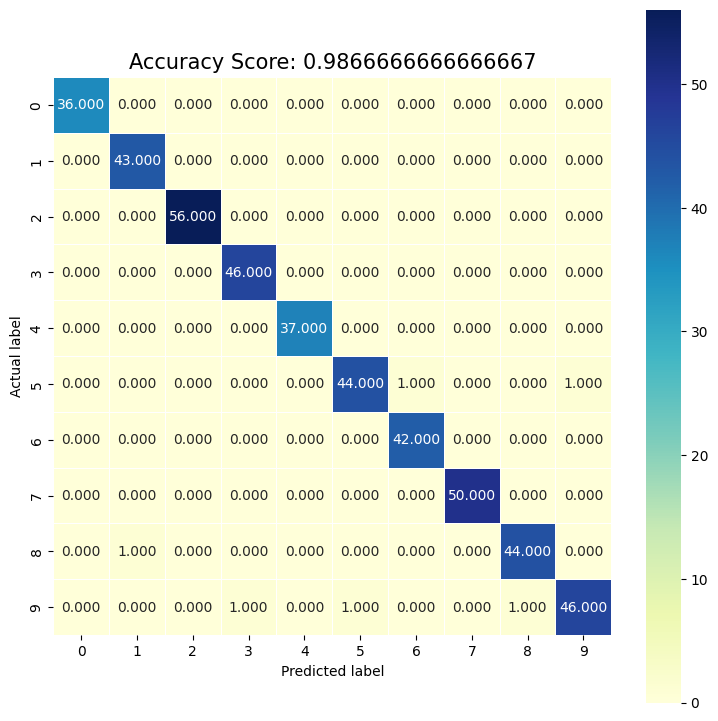

In [44]:
import seaborn as sns
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5,square = True, cmap = 'YlGnBu')
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(score)
plt.title(all_sample_title, size = 15);

## Optimizing Example II

The digits model used an arbitrary `k = 3` on a single split. We validate it with **cross-validation** and let **grid search** find the best `k` and weighting scheme.

In [45]:
# Cross-validate the original k=3 model
cv_scores_digits = cross_val_score(KNeighborsClassifier(n_neighbors=3), x_train, y_train, cv=5)
print("k=3  ->  5-fold CV accuracy: {:.3f} (+/- {:.3f})".format(
    cv_scores_digits.mean(), cv_scores_digits.std()))

# Grid search over k and weighting scheme
param_grid_digits = {'n_neighbors': np.arange(1, 21), 'weights': ['uniform', 'distance']}
grid_digits = GridSearchCV(KNeighborsClassifier(), param_grid_digits, cv=5, scoring='accuracy')
grid_digits.fit(x_train, y_train)

print("\nBest params:", grid_digits.best_params_)
print("Best CV accuracy: {:.3f}".format(grid_digits.best_score_))
print("Tuned model test accuracy:  {:.3f}".format(grid_digits.best_estimator_.score(x_test, y_test)))
print("Original k=3 test accuracy: {:.3f}".format(score))

k=3  ->  5-fold CV accuracy: 0.984 (+/- 0.012)

Best params: {'n_neighbors': np.int64(1), 'weights': 'uniform'}
Best CV accuracy: 0.987
Tuned model test accuracy:  0.984
Original k=3 test accuracy: 0.987


# Example III: Breast Cancer Diagnosis

Here we apply KNN to the built-in **Breast Cancer Wisconsin** dataset from *sklearn*. It contains 569 tumor samples described by 30 numeric features (radius, texture, perimeter, area, smoothness, etc.), and the task is to classify each tumor as **malignant** or **benign**.

In a medical diagnostic setting, overall accuracy is not enough — a *false negative* (missing a malignant tumor) is far more dangerous than a false positive. So we focus on **precision, recall, and ROC-AUC** in addition to accuracy.

In [46]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_c = cancer.data
y_c = cancer.target  # 0 = malignant, 1 = benign

print("Data shape:", X_c.shape)
print("Target classes:", cancer.target_names)
print("Class distribution:", np.bincount(y_c))

# Split into training and test sets (stratified to keep class balance)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.25, random_state=0, stratify=y_c
)

Data shape: (569, 30)
Target classes: ['malignant' 'benign']
Class distribution: [212 357]


In [47]:
# Feature scaling: essential for KNN since features have very different ranges
sc_cancer = StandardScaler()
X_train_c = sc_cancer.fit_transform(X_train_c)
X_test_c = sc_cancer.transform(X_test_c)

# Train KNN classifier
cancer_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
cancer_clf.fit(X_train_c, y_train_c)

y_pred_c = cancer_clf.predict(X_test_c)
print("Test accuracy: {:.3f}".format(cancer_clf.score(X_test_c, y_test_c)))

Test accuracy: 0.951


## Evaluating with precision, recall, and the confusion matrix

For diagnosis we care most about **recall for the malignant class** — the fraction of actual malignant tumors the model correctly catches. A missed malignant case (false negative) is the most costly error.

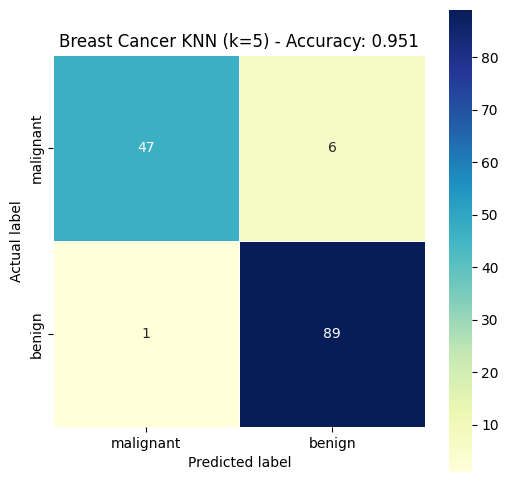

              precision    recall  f1-score   support

   malignant       0.98      0.89      0.93        53
      benign       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



In [48]:
from sklearn.metrics import classification_report

cm_cancer = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_cancer, annot=True, fmt="d", linewidths=.5, square=True, cmap='YlGnBu',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.title('Breast Cancer KNN (k=5) - Accuracy: {:.3f}'.format(cancer_clf.score(X_test_c, y_test_c)))
plt.show()

print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))

## ROC curve and AUC

The ROC curve shows the trade-off between the true positive rate and false positive rate across all decision thresholds. The **AUC** (area under the curve) summarizes this in a single number, where 1.0 is perfect and 0.5 is random guessing. We use the predicted probability of the malignant class.

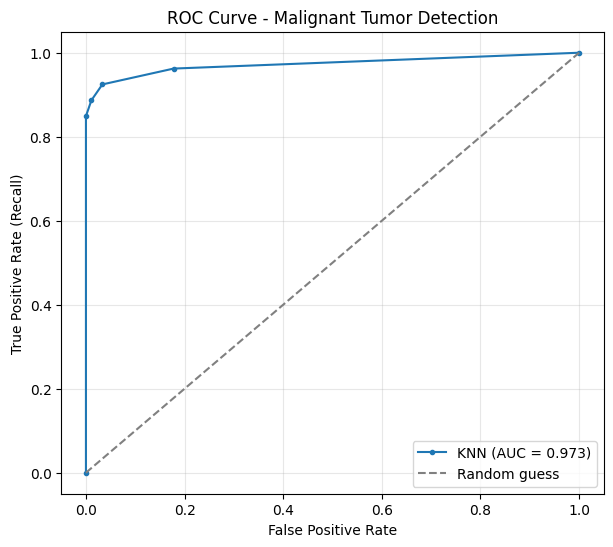

ROC-AUC: 0.973


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score

# Treat "malignant" (class 0) as the positive class of interest
malignant_idx = list(cancer.target_names).index('malignant')
y_scores = cancer_clf.predict_proba(X_test_c)[:, malignant_idx]

fpr, tpr, thresholds = roc_curve(y_test_c, y_scores, pos_label=malignant_idx)
auc = roc_auc_score((y_test_c == malignant_idx).astype(int), y_scores)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, marker='.', label='KNN (AUC = {:.3f})'.format(auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Malignant Tumor Detection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ROC-AUC: {:.3f}".format(auc))

# Validating the Hyperparameter *k*

So far we evaluated KNN on a single train/test split. As the lessons in week 5 stressed, a single holdout split can be misleading — a more robust estimate comes from **cross-validation**, and the best hyperparameter should be chosen with a **validation curve**, a **learning curve**, and finally an automated **grid search**. Here we apply each of those tools to KNN's main knob, `n_neighbors` (*k*).

## 1. Cross-validation

Instead of trusting one split, we use 5-fold cross-validation (`cross_val_score`) to get a more reliable estimate of accuracy and its variability.

In [50]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(cancer_clf, X_train_c, y_train_c, cv=5)
print("5-fold CV accuracies:", np.round(cv_scores, 3))
print("Mean CV accuracy: {:.3f} (+/- {:.3f})".format(cv_scores.mean(), cv_scores.std()))

5-fold CV accuracies: [0.942 0.976 0.941 0.988 0.953]
Mean CV accuracy: 0.960 (+/- 0.019)


## 2. Validation curve for *k*

The validation curve plots the training and cross-validated scores as we vary a single hyperparameter. For KNN, **small *k* = high variance/overfitting** (high train score, lower validation score) and **large *k* = high bias/underfitting** (both scores drop). The best *k* sits where the validation score peaks.

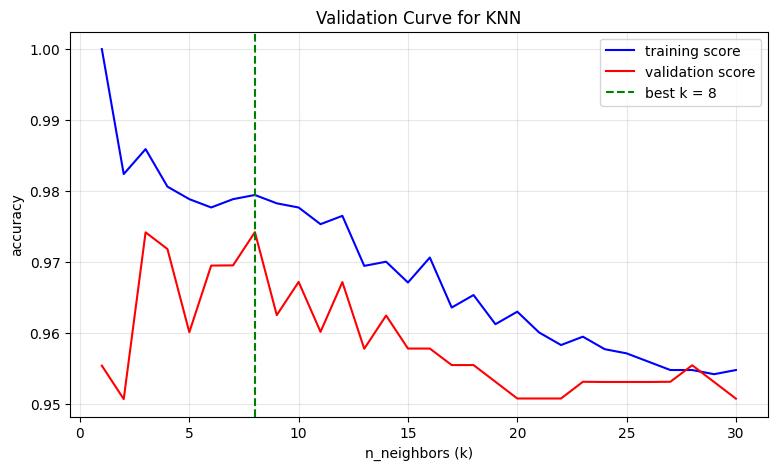

Best k from validation curve: 8


In [51]:
from sklearn.model_selection import validation_curve

k_range = np.arange(1, 31)
train_score, val_score = validation_curve(
    KNeighborsClassifier(), X_train_c, y_train_c,
    param_name='n_neighbors', param_range=k_range, cv=5)

plt.figure(figsize=(9, 5))
plt.plot(k_range, np.mean(train_score, axis=1), color='blue', label='training score')
plt.plot(k_range, np.mean(val_score, axis=1), color='red', label='validation score')
best_k = k_range[np.argmax(np.mean(val_score, axis=1))]
plt.axvline(best_k, color='green', linestyle='--', label='best k = {}'.format(best_k))
plt.xlabel('n_neighbors (k)')
plt.ylabel('accuracy')
plt.title('Validation Curve for KNN')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print("Best k from validation curve:", best_k)

## 3. Learning curve

The learning curve shows how the training and validation scores evolve as the training set grows. If the two curves have converged, adding more data won't help; a persistent gap indicates the model could benefit from more data or lower complexity.

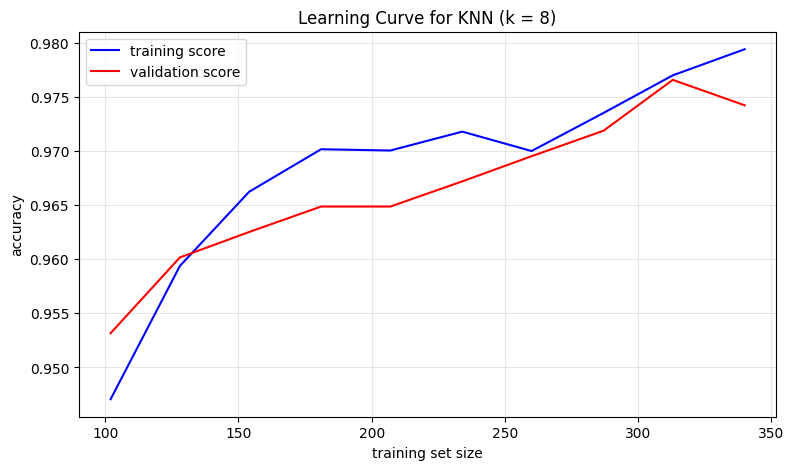

In [52]:
from sklearn.model_selection import learning_curve

N, train_lc, val_lc = learning_curve(
    KNeighborsClassifier(n_neighbors=best_k), X_train_c, y_train_c,
    cv=5, train_sizes=np.linspace(0.3, 1.0, 10))

plt.figure(figsize=(9, 5))
plt.plot(N, np.mean(train_lc, axis=1), color='blue', label='training score')
plt.plot(N, np.mean(val_lc, axis=1), color='red', label='validation score')
plt.xlabel('training set size')
plt.ylabel('accuracy')
plt.title('Learning Curve for KNN (k = {})'.format(best_k))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Grid search

Real models have several hyperparameters. `GridSearchCV` automatically cross-validates every combination and keeps the best. Here we tune `n_neighbors`, `weights` (uniform vs. distance-weighted voting), and `p` (Manhattan vs. Euclidean distance), then evaluate the best model on the held-out test set.

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'p': [1, 2],  # 1 = Manhattan, 2 = Euclidean
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_c, y_train_c)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy: {:.3f}".format(grid.best_score_))

# Evaluate the tuned model on the untouched test set
best_model = grid.best_estimator_
print("Test accuracy of tuned model: {:.3f}".format(best_model.score(X_test_c, y_test_c)))

Best parameters: {'n_neighbors': np.int64(4), 'p': 1, 'weights': 'distance'}
Best CV accuracy: 0.979
Test accuracy of tuned model: 0.958
